In [37]:
import zipfile
import os

zip_path = "/content/test.zip"   # put your file name here

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/test")

print("Extraction done!")

Extraction done!


In [38]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# PARAMETERS

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25

In [39]:
DATASET_PATH = "/content/test"


# IMAGE DATA GENERATOR

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [40]:
# LOAD DATA

train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation'
)

class_names = list(train_data.class_indices.keys())
print("Classes:", class_names)

Found 288 images belonging to 36 classes.
Found 71 images belonging to 36 classes.
Classes: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


In [41]:
#CNN Model
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(256, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D())

model.add(layers.Flatten())

model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(len(class_names), activation='softmax'))

In [42]:
# COMPILE

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,837,028 (37.53 MB)

 Trainable params: 9,836,068 (37.52 MB)

 Non-trainable params: 960 (3.75 KB)

In [43]:
# TRAIN

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Epoch 1/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 78s 8s/step - accuracy: 0.0556 - loss: 13.9601 - val_accuracy: 0.0423 - val_loss: 3.9535
Epoch 2/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 71s 8s/step - accuracy: 0.0833 - loss: 9.1361 - val_accuracy: 0.0141 - val_loss: 4.6219
Epoch 3/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 83s 8s/step - accuracy: 0.0972 - loss: 5.6282 - val_accuracy: 0.0423 - val_loss: 4.2070
Epoch 4/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 82s 8s/step - accuracy: 0.0938 - loss: 4.4390 - val_accuracy: 0.0704 - val_loss: 4.3101
Epoch 5/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 71s 8s/step - accuracy: 0.0903 - loss: 3.6832 - val_accuracy: 0.0423 - val_loss: 6.8646
Epoch 6/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 71s 8s/step - accuracy: 0.0799 - loss: 3.6845 - val_accuracy: 0.0563 - val_loss: 8.8813
Epoch 7/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 71s 8s/step - accuracy: 0.1076 - loss: 3.4822 - val_accuracy: 0.0282 - val_loss: 7.6452
Epoch 8/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 71s 8s/step - accuracy: 0.1042 - loss: 3.6108 - val_accuracy: 0.0282 - val_loss: 8.1503
Epoch 9

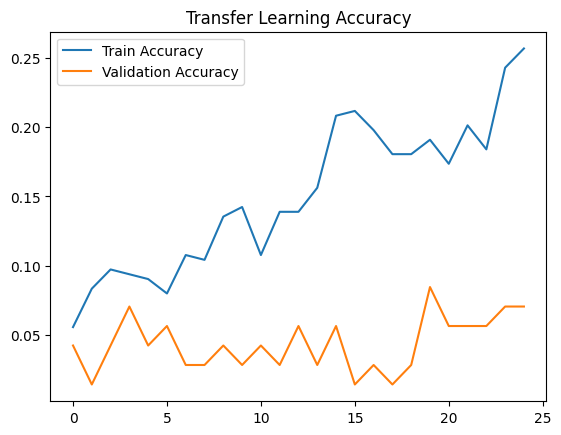

In [44]:
# SAVE MODEL
model.save("/content/fruit_veg_transfer_model.h5")

# PLOT
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Transfer Learning Accuracy")
plt.show()